In [126]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


In [127]:
df=pd.read_csv('processed.cleveland.data')


In [128]:
df.head()


,63.0,1.0,1.0.1,145.0,233.0,1.0.2,2.0,150.0,0.0,2.3,3.0,0.0.1,6.0,0
0,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
1,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
2,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
3,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0
4,56.0,1.0,2.0,120.0,236.0,0.0,0.0,178.0,0.0,0.8,1.0,0.0,3.0,0


In [129]:
df.columns=[
'age',
'sex',
'cp',
'trestbps',
'chol',
'fbs',
'restecg',  
'thalach',
'exang',
'oldpeak',
'slope',
'ca',
'thal',
'hd'
]
df.head()


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,hd
0,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
1,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
2,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
3,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0
4,56.0,1.0,2.0,120.0,236.0,0.0,0.0,178.0,0.0,0.8,1.0,0.0,3.0,0


In [130]:
df.isnull().sum()


age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
hd          0
dtype: int64

In [131]:
df.isna().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
hd          0
dtype: int64

In [132]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 302 entries, 0 to 301
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       302 non-null    float64
 1   sex       302 non-null    float64
 2   cp        302 non-null    float64
 3   trestbps  302 non-null    float64
 4   chol      302 non-null    float64
 5   fbs       302 non-null    float64
 6   restecg   302 non-null    float64
 7   thalach   302 non-null    float64
 8   exang     302 non-null    float64
 9   oldpeak   302 non-null    float64
 10  slope     302 non-null    float64
 11  ca        302 non-null    str    
 12  thal      302 non-null    str    
 13  hd        302 non-null    int64  
dtypes: float64(11), int64(1), str(2)
memory usage: 34.9 KB


In [133]:
df['ca'].unique()

<ArrowStringArray>
['3.0', '2.0', '0.0', '1.0', '?']
Length: 5, dtype: str

In [134]:
df['thal'].unique()

<ArrowStringArray>
['3.0', '7.0', '6.0', '?']
Length: 4, dtype: str

In [135]:
len(df.loc[(df['ca']=='?') | (df['thal']=='?')])

6

In [136]:
df.loc[(df['ca']=='?') | (df['thal']=='?')]

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,hd
86,53.0,0.0,3.0,128.0,216.0,0.0,2.0,115.0,0.0,0.0,1.0,0.0,?,0
165,52.0,1.0,3.0,138.0,223.0,0.0,0.0,169.0,0.0,0.0,1.0,?,3.0,0
191,43.0,1.0,4.0,132.0,247.0,1.0,2.0,143.0,1.0,0.1,2.0,?,7.0,1
265,52.0,1.0,4.0,128.0,204.0,1.0,0.0,156.0,1.0,1.0,2.0,0.0,?,2
286,58.0,1.0,2.0,125.0,220.0,0.0,0.0,144.0,0.0,0.4,2.0,?,7.0,0
301,38.0,1.0,3.0,138.0,175.0,0.0,0.0,173.0,0.0,0.0,1.0,?,3.0,0


In [137]:
len(df)

302

In [138]:
#only 6 rows have missing values, so we can drop them without losing much information
df.drop(df.loc[(df['ca']=='?') | (df['thal']=='?')].index, inplace=True)

In [139]:
df.info()

<class 'pandas.DataFrame'>
Index: 296 entries, 0 to 300
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       296 non-null    float64
 1   sex       296 non-null    float64
 2   cp        296 non-null    float64
 3   trestbps  296 non-null    float64
 4   chol      296 non-null    float64
 5   fbs       296 non-null    float64
 6   restecg   296 non-null    float64
 7   thalach   296 non-null    float64
 8   exang     296 non-null    float64
 9   oldpeak   296 non-null    float64
 10  slope     296 non-null    float64
 11  ca        296 non-null    str    
 12  thal      296 non-null    str    
 13  hd        296 non-null    int64  
dtypes: float64(11), int64(1), str(2)
memory usage: 36.5 KB


In [140]:
df['thal'].unique()

<ArrowStringArray>
['3.0', '7.0', '6.0']
Length: 3, dtype: str

In [141]:
df['ca'].unique()

<ArrowStringArray>
['3.0', '2.0', '0.0', '1.0']
Length: 4, dtype: str

In [142]:
from sklearn.model_selection import train_test_split

In [143]:
X = df.drop('hd', axis=1)
y = df['hd']

In [144]:
#onehotencoding
pd.get_dummies(X, columns=['cp']).head()

,age,sex,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,cp_1.0,cp_2.0,cp_3.0,cp_4.0
0,67.0,1.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,False,False,False,True
1,67.0,1.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,False,False,False,True
2,37.0,1.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,False,False,True,False
3,41.0,0.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,False,True,False,False
4,56.0,1.0,120.0,236.0,0.0,0.0,178.0,0.0,0.8,1.0,0.0,3.0,False,True,False,False


In [145]:
X_encoded = pd.get_dummies(
    X, columns=['cp', 'restecg', 'slope', 'thal']
)

In [146]:
X_encoded.head()

,age,sex,trestbps,chol,fbs,thalach,exang,oldpeak,ca,cp_1.0,...,cp_4.0,restecg_0.0,restecg_1.0,restecg_2.0,slope_1.0,slope_2.0,slope_3.0,thal_3.0,thal_6.0,thal_7.0
0,67.0,1.0,160.0,286.0,0.0,108.0,1.0,1.5,3.0,False,...,True,False,False,True,False,True,False,True,False,False
1,67.0,1.0,120.0,229.0,0.0,129.0,1.0,2.6,2.0,False,...,True,False,False,True,False,True,False,False,False,True
2,37.0,1.0,130.0,250.0,0.0,187.0,0.0,3.5,0.0,False,...,False,True,False,False,False,False,True,True,False,False
3,41.0,0.0,130.0,204.0,0.0,172.0,0.0,1.4,0.0,False,...,False,False,False,True,True,False,False,True,False,False
4,56.0,1.0,120.0,236.0,0.0,178.0,0.0,0.8,0.0,False,...,False,True,False,False,True,False,False,True,False,False


In [147]:
y.unique()

array([2, 1, 0, 3, 4])

In [148]:
# here we have four classes, but we will convert it to binary classification by replacing all values greater than 0 with 1
# cause in this dataset we only care if somwonw has heart disease or not, we dont care about the severity of the disease
y_not_zero_index = y > 0
y[y_not_zero_index] = 1
y.unique()

array([1, 0])

In [149]:
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, random_state=42)

In [150]:
#creating dt and fiting on traininig data
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)


,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

[Text(0.5194444444444445, 0.9444444444444444, 'cp_4.0 <= 0.5\ngini = 0.499\nsamples = 222\nvalue = [116, 106]\nclass = No Disease'),
 Text(0.2611111111111111, 0.8333333333333334, 'slope_2.0 <= 0.5\ngini = 0.354\nsamples = 113\nvalue = [87, 26]\nclass = No Disease'),
 Text(0.39027777777777783, 0.8888888888888888, 'True  '),
 Text(0.14444444444444443, 0.7222222222222222, 'trestbps <= 185.0\ngini = 0.198\nsamples = 72\nvalue = [64, 8]\nclass = No Disease'),
 Text(0.12222222222222222, 0.6111111111111112, 'age <= 56.5\ngini = 0.178\nsamples = 71\nvalue = [64.0, 7.0]\nclass = No Disease'),
 Text(0.044444444444444446, 0.5, 'slope_3.0 <= 0.5\ngini = 0.043\nsamples = 45\nvalue = [44, 1]\nclass = No Disease'),
 Text(0.022222222222222223, 0.3888888888888889, 'gini = 0.0\nsamples = 40\nvalue = [40, 0]\nclass = No Disease'),
 Text(0.06666666666666667, 0.3888888888888889, 'thal_3.0 <= 0.5\ngini = 0.32\nsamples = 5\nvalue = [4, 1]\nclass = No Disease'),
 Text(0.044444444444444446, 0.2777777777777778,

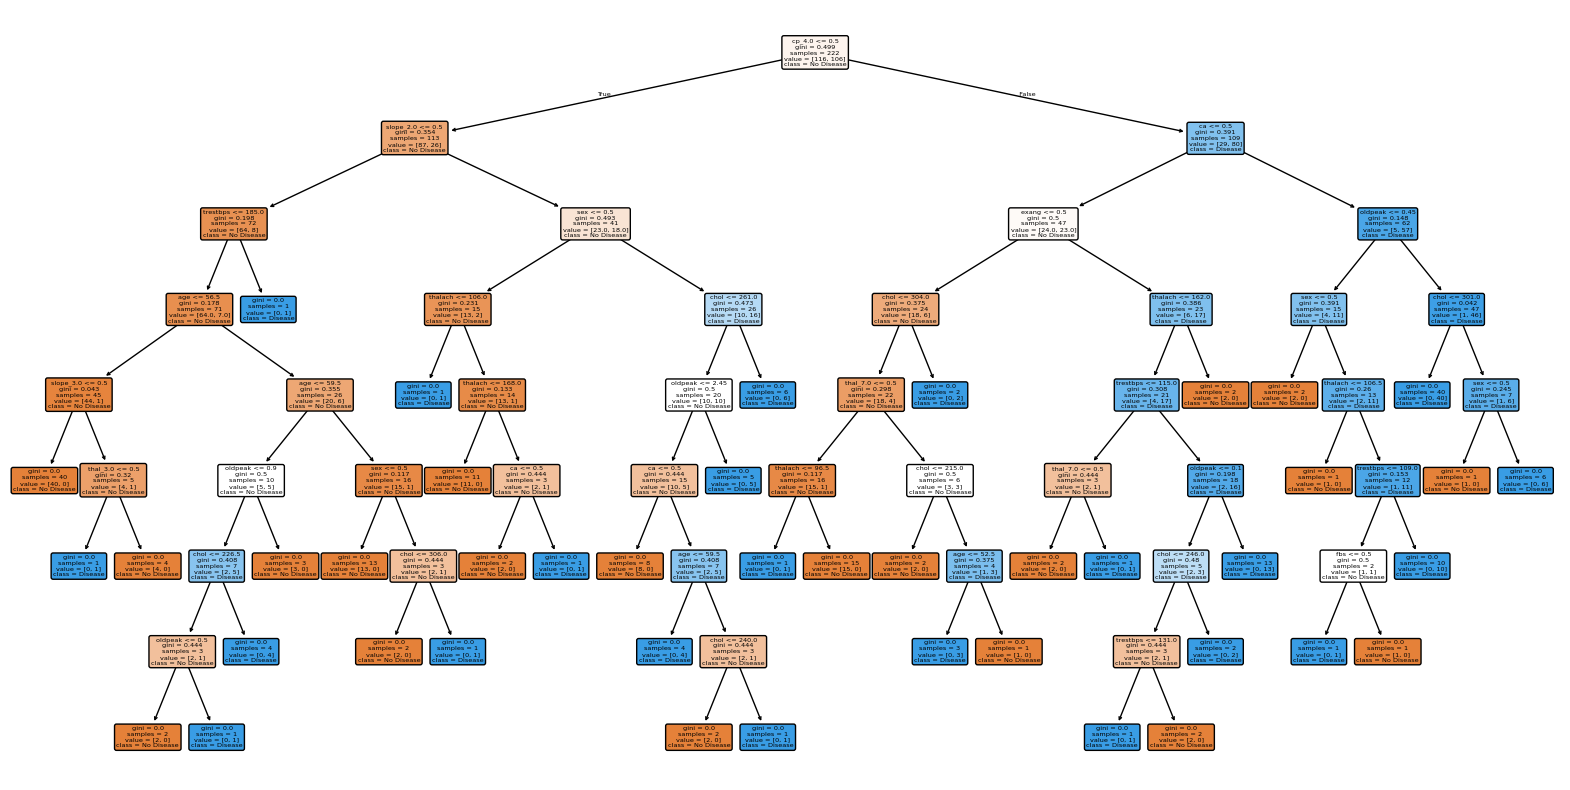

In [151]:
#plotting the tree
plt.figure(figsize=(20,10))
from sklearn.tree import plot_tree
plot_tree(dt, filled=True, rounded=True, class_names=['No Disease', 'Disease'], feature_names=X_encoded.columns)

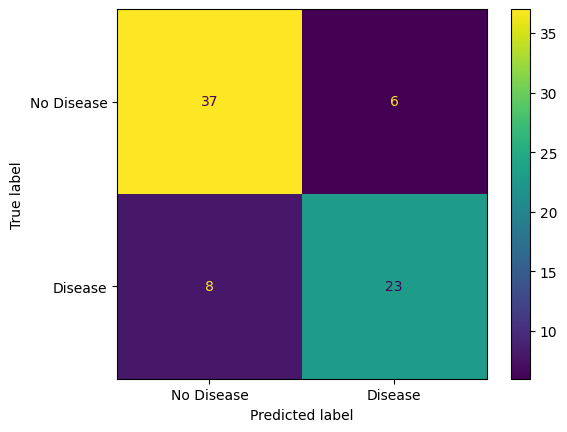

In [152]:
#plot the confusion matrix and will run on test data
from sklearn.metrics import ConfusionMatrixDisplay


ConfusionMatrixDisplay.from_estimator(dt, X_test, y_test,   display_labels=['No Disease', 'Disease'])

In [153]:
#one thing we always need to notice is can we do better
# and we have to look at the tree and see can we reduce the depth of the tree and make it more generalizeable to new data
# there are so many leaf nodes in the tree and that means the tree is overfitting the training data and it will not perform well on new data


In [154]:
#Preventing overfitting by cost complexity pruning
# we can use the cost complexity pruning to reduce the depth of the tree and make it more
# 

path = dt.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas
ccp_alphas=ccp_alphas[:-1]

cf_dts = []
for ccp_alpha in ccp_alphas:
    dt = DecisionTreeClassifier(random_state=42, ccp_alpha=ccp_alpha)
    dt.fit(X_train, y_train)
    cf_dts.append(dt)

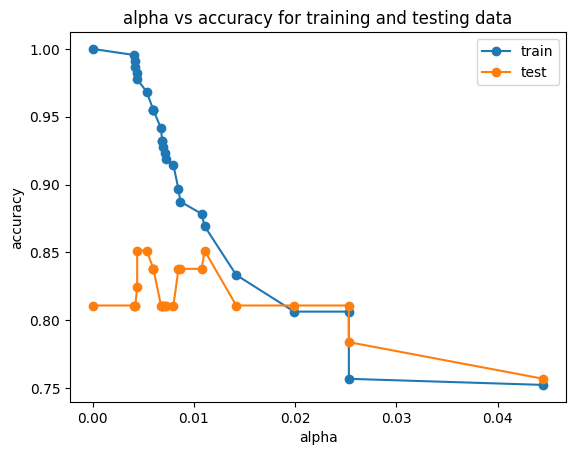

In [155]:
#Ploting the graph of the alpha vs the accuracy of the model on the test data and training data
train_scores = [dt.score(X_train, y_train) for dt in cf_dts]
test_scores = [dt.score(X_test, y_test) for dt in cf_dts]

fig, ax = plt.subplots()
ax.set_xlabel('alpha')
ax.set_ylabel('accuracy')
ax.set_title('alpha vs accuracy for training and testing data')
ax.plot(ccp_alphas, train_scores, label='train', marker='o')
ax.plot(ccp_alphas, test_scores, label='test', marker='o')
ax.legend()
plt.show()

<Axes: xlabel='tree'>

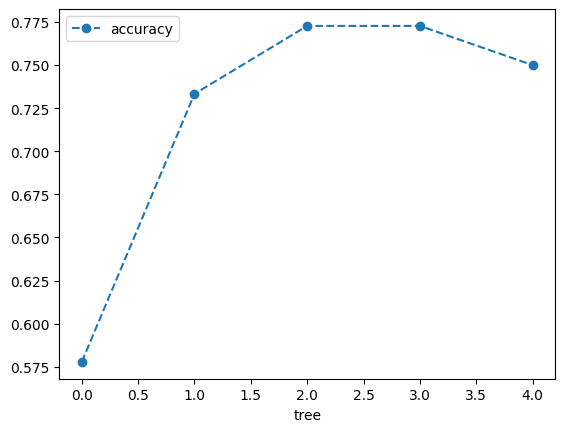

In [158]:
#cross validation to find the best alpha value
from sklearn.model_selection import cross_val_score
dt = DecisionTreeClassifier(random_state=42, ccp_alpha=0.025)
scores = cross_val_score(dt, X_train, y_train, cv=5)
df=pd.DataFrame(data={'tree': range(5), 'accuracy': scores})
df.plot(x='tree', y='accuracy', marker='o',linestyle='--')

<Axes: xlabel='alpha'>

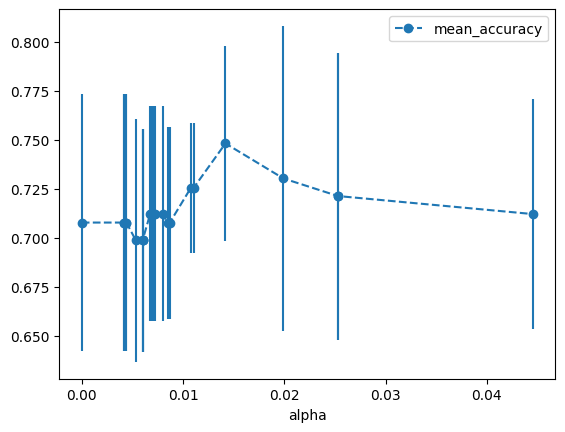

In [159]:
#creating an array to store the values of each fold during cross validation
alpha_loop_values = []
for ccp_alpha in ccp_alphas:
    dt = DecisionTreeClassifier(random_state=42, ccp_alpha=ccp_alpha)
    scores = cross_val_score(dt, X_train, y_train, cv=5)
    alpha_loop_values.append([ccp_alpha, np.mean(scores), np.std(scores)])

alpha_results = pd.DataFrame(alpha_loop_values, columns=['alpha', 'mean_accuracy', 'std'])
alpha_results.plot(x='alpha', y='mean_accuracy', yerr='std', marker='o', linestyle='--')


In [160]:
alpha_results[(alpha_results['alpha']>0.014) & (alpha_results['alpha']<0.015)]

,alpha,mean_accuracy,std
21,0.01419,0.748182,0.049741


In [170]:
ideal_ccp_alpha = alpha_results[(alpha_results['alpha']>0.014) & (alpha_results['alpha']<0.015)]['alpha'].values[0]
ideal_ccp_alpha

np.float64(0.014190014190014191)

In [171]:
#Evaluating and Interpreting the final dt
dt_pruned = DecisionTreeClassifier(random_state=42, ccp_alpha=ideal_ccp_alpha)

In [172]:
dt_pruned=dt_pruned.fit(X_train, y_train)

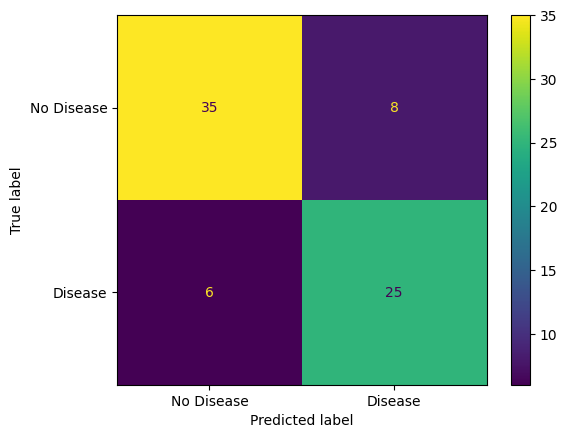

In [173]:
ConfusionMatrixDisplay.from_estimator(dt_pruned, X_test, y_test,   display_labels=['No Disease', 'Disease'])

[Text(0.5, 0.875, 'cp_4.0 <= 0.5\ngini = 0.499\nsamples = 222\nvalue = [116, 106]\nclass = No Disease'),
 Text(0.2, 0.625, 'slope_2.0 <= 0.5\ngini = 0.354\nsamples = 113\nvalue = [87, 26]\nclass = No Disease'),
 Text(0.35, 0.75, 'True  '),
 Text(0.1, 0.375, 'gini = 0.198\nsamples = 72\nvalue = [64, 8]\nclass = No Disease'),
 Text(0.3, 0.375, 'sex <= 0.5\ngini = 0.493\nsamples = 41\nvalue = [23.0, 18.0]\nclass = No Disease'),
 Text(0.2, 0.125, 'gini = 0.231\nsamples = 15\nvalue = [13, 2]\nclass = No Disease'),
 Text(0.4, 0.125, 'gini = 0.473\nsamples = 26\nvalue = [10, 16]\nclass = Disease'),
 Text(0.8, 0.625, 'ca <= 0.5\ngini = 0.391\nsamples = 109\nvalue = [29, 80]\nclass = Disease'),
 Text(0.65, 0.75, '  False'),
 Text(0.7, 0.375, 'exang <= 0.5\ngini = 0.5\nsamples = 47\nvalue = [24.0, 23.0]\nclass = No Disease'),
 Text(0.6, 0.125, 'gini = 0.375\nsamples = 24\nvalue = [18, 6]\nclass = No Disease'),
 Text(0.8, 0.125, 'gini = 0.386\nsamples = 23\nvalue = [6, 17]\nclass = Disease'),
 Te

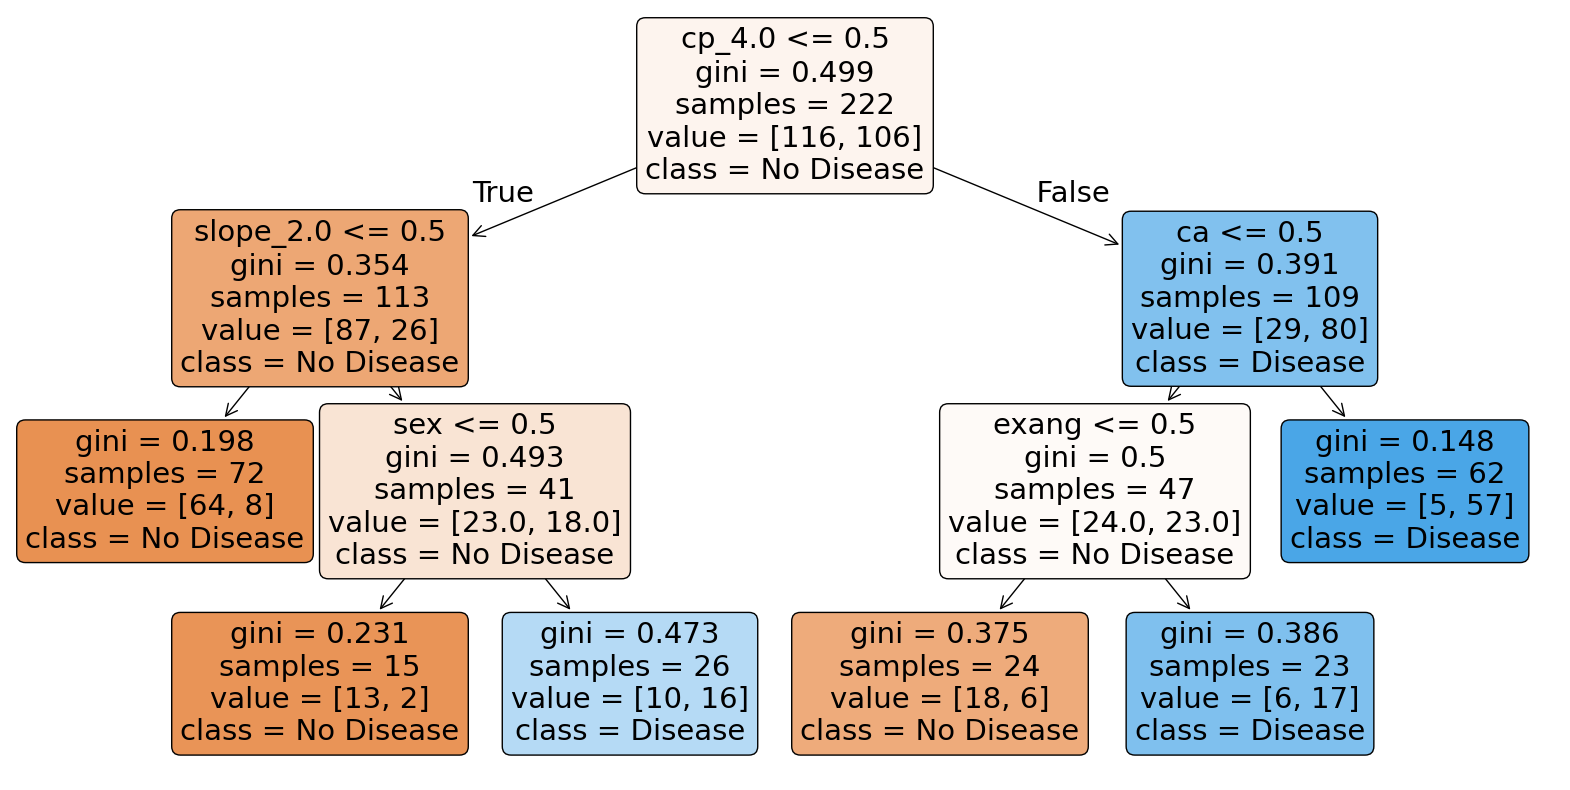

In [174]:
plt.figure(figsize=(20,10))
plot_tree(dt_pruned, filled=True, rounded=True, class_names=['No Disease', 'Disease'], feature_names=X_encoded.columns)
